<a href="https://colab.research.google.com/github/teevvr7/Football_penalty/blob/main/pose%26LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install dependencies
!pip install ultralytics opencv-python mediapipe

INFO: pip is looking at multiple versions of mediapipe to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 31.2 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.13.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.8 which is incompatible.


In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Check your Drive structure
print("Checking your Drive folder structure:")
!ls -la "/content/drive/MyDrive/"

# Copy from Drive to Colab for faster training (RECOMMENDED)
import shutil
import os

# Copy entire project to Colab
source_path = "/content/drive/MyDrive/penalty_project"
dest_path = "/content/penalty_project"

if os.path.exists(source_path):
    if os.path.exists(dest_path):
        shutil.rmtree(dest_path)  # Remove existing
    shutil.copytree(source_path, dest_path)
    print("✓ Copied files from Drive to Colab")
else:
    print("⚠ penalty_project folder not found in Drive")
    print("Please make sure your files are in: /content/drive/MyDrive/penalty_project/")

Mounted at /content/drive
Checking your Drive folder structure:
total 33224
-rw------- 1 root root  141712 Jun  6  2024  2e90d0c1-e67c-4512-9b38-80a7e931e4f2.jpeg
-rw------- 1 root root  114244 Apr 15 09:16 '5.Individual SCL1 -video In the Shoes of the Entrepreneur(217093).pdf'
-rw------- 1 root root  166691 May 27  2024  ae58282b-0a94-4b59-880d-4eb52ec85e5d.jpeg
-rw------- 1 root root     180 Jan  9  2025 'CEL GROUP 4-discussion plan.gdoc'
drwx------ 2 root root    4096 Jun 12  2024 'Colab Notebooks'
-rw------- 1 root root     180 Jan  9  2024 'Copy of ASURAN CHAMPIONSHIP 2.0 CREW RECRUITMENT (Responses).gsheet'
-rw------- 1 root root 2955861 Apr  3  2024  DC00949F-E821-4A66-95EE-A6B6B084E4BF.jpeg
-rw------- 1 root root  745924 Nov 24  2024  donut.blend
-rw------- 1 root root     180 Jul  6 10:53 'Draft of FYP teev(217093).gdoc'
-rw------- 1 root root  126129 May 16 12:01  fbf6f6c1-d3c0-4658-ba56-e144120f454f.jpeg
-rw------- 1 root root  154157 Nov 15  2024  food_consumption.csv
-rw--

In [2]:
!cp -r "/content/drive/MyDrive/yolov8n.pt" "/content/"

In [3]:
!cp -r "/content/drive/MyDrive/runs" "/content/"

In [4]:
!cp -r "/content/drive/MyDrive/yolo11n.pt" "/content/"

##Complete Pose Extraction Pipeline

In [17]:
import cv2
import mediapipe as mp
from ultralytics import YOLO
import numpy as np
import os
from tqdm import tqdm

# Load your trained YOLO model
yolo_model = YOLO('/content/runs/detect/train/weights/best.pt')

# Initialize MediaPipe Pose
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode=False, model_complexity=1, min_detection_confidence=0.5)

def extract_pose_sequence(video_path, sequence_length=30):
    """
    Extract 30-frame pose sequences from video for LSTM training
    Returns: pose sequence (30, 132) or None if failed
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"❌ Cannot open video: {video_path}")
        return None

    pose_sequences = []
    frames_processed = 0

    # Get total frames to show progress
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Start from frame 10 to avoid initial static frames
    cap.set(cv2.CAP_PROP_POS_FRAMES, 10)

    with tqdm(total=sequence_length, desc=f"Extracting poses") as pbar:
        while frames_processed < sequence_length:
            ret, frame = cap.read()
            if not ret:
                break

            # Detect objects using YOLO
            results = yolo_model(frame, verbose=False)

            # Find kicker bounding box (class index 0)
            kicker_box = None
            for result in results:
                for box in result.boxes:
                    if int(box.cls) == 0:  # kicker class
                        kicker_box = box.xyxy[0].cpu().numpy()
                        break
                if kicker_box is not None:
                    break

            if kicker_box is not None:
                # Extract kicker region
                x1, y1, x2, y2 = map(int, kicker_box)

                # Add padding to ensure we capture full body
                padding = 20
                x1 = max(0, x1 - padding)
                y1 = max(0, y1 - padding)
                x2 = min(frame.shape[1], x2 + padding)
                y2 = min(frame.shape[0], y2 + padding)

                kicker_crop = frame[y1:y2, x1:x2]

                # Skip if crop is too small
                if kicker_crop.shape[0] < 50 or kicker_crop.shape[1] < 50:
                    continue

                # Extract pose landmarks
                rgb_frame = cv2.cvtColor(kicker_crop, cv2.COLOR_BGR2RGB)
                pose_results = pose.process(rgb_frame)

                if pose_results.pose_landmarks:
                    landmarks = []
                    for landmark in pose_results.pose_landmarks.landmark:
                        landmarks.extend([landmark.x, landmark.y, landmark.z, landmark.visibility])

                    pose_sequences.append(landmarks)
                    frames_processed += 1
                    pbar.update(1)

    cap.release()

    if len(pose_sequences) == sequence_length:
        return np.array(pose_sequences)
    else:
        print(f"⚠ Only got {len(pose_sequences)} frames out of {sequence_length}")
        return None

# Test pose extraction on one video
print("🧪 Testing pose extraction...")
test_video = "/content/penalty_project/videos/108outside.mp4"
test_sequence = extract_pose_sequence(test_video)

if test_sequence is not None:
    print(f"✅ Success! Sequence shape: {test_sequence.shape}")
else:
    print("❌ Pose extraction failed")

🧪 Testing pose extraction...


Extracting poses: 100%|██████████| 30/30 [00:01<00:00, 22.57it/s]

✅ Success! Sequence shape: (30, 132)


##Debuggin cuz 109 not detected by mediapipe

In [21]:
import cv2
import mediapipe as mp
from ultralytics import YOLO
import numpy as np
import os
from tqdm import tqdm

# Load your trained YOLO model
yolo_model = YOLO('/content/runs/detect/train/weights/best.pt')

# Initialize MediaPipe Pose
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode=False, model_complexity=1, min_detection_confidence=0.3)  # Lower confidence

def extract_pose_sequence_debug(video_path, sequence_length=30):
    """
    Improved pose extraction with better debugging
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"❌ Cannot open video: {video_path}")
        return None

    pose_sequences = []
    frames_processed = 0
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    print(f"📹 Video: {os.path.basename(video_path)}")
    print(f"Total frames: {total_frames}")

    # Try different starting points to find kicker
    start_positions = [0, 10, 20, 30]

    for start_frame in start_positions:
        if frames_processed >= sequence_length:
            break

        cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
        print(f"🔍 Trying start frame: {start_frame}")

        with tqdm(total=sequence_length-frames_processed, desc="Extracting poses") as pbar:
            while frames_processed < sequence_length:
                ret, frame = cap.read()
                if not ret:
                    break

                # Detect objects using YOLO
                results = yolo_model(frame, verbose=False)

                # Find kicker bounding box (class index 0)
                kicker_box = None
                for result in results:
                    for box in result.boxes:
                        if int(box.cls) == 0 and box.conf > 0.5:  # kicker with good confidence
                            kicker_box = box.xyxy[0].cpu().numpy()
                            break
                    if kicker_box is not None:
                        break

                if kicker_box is not None:
                    # Extract kicker region
                    x1, y1, x2, y2 = map(int, kicker_box)

                    # Add padding
                    padding = 30  # Increased padding
                    x1 = max(0, x1 - padding)
                    y1 = max(0, y1 - padding)
                    x2 = min(frame.shape[1], x2 + padding)
                    y2 = min(frame.shape[0], y2 + padding)

                    kicker_crop = frame[y1:y2, x1:x2]

                    # Skip if crop is too small
                    if kicker_crop.shape[0] < 40 or kicker_crop.shape[1] < 40:
                        continue

                    # Extract pose landmarks
                    rgb_frame = cv2.cvtColor(kicker_crop, cv2.COLOR_BGR2RGB)
                    pose_results = pose.process(rgb_frame)

                    if pose_results.pose_landmarks:
                        landmarks = []
                        for landmark in pose_results.pose_landmarks.landmark:
                            landmarks.extend([landmark.x, landmark.y, landmark.z, landmark.visibility])

                        pose_sequences.append(landmarks)
                        frames_processed += 1
                        pbar.update(1)
                else:
                    # If no kicker detected, try next frame
                    pass

                # Stop if we've processed too many frames without success
                if cap.get(cv2.CAP_PROP_POS_FRAMES) > total_frames * 0.8:  # Stop after 80% of video
                    break

    cap.release()

    if len(pose_sequences) == sequence_length:
        print(f"✅ Success! Extracted {len(pose_sequences)} frames")
        return np.array(pose_sequences)
    else:
        print(f"⚠ Only got {len(pose_sequences)} frames out of {sequence_length}")

        # If we have some frames but not enough, pad with zeros or repeat last frame
        if len(pose_sequences) > 10:  # If we have at least 10 good frames
            print("🔄 Padding sequence with last frame repetition...")
            while len(pose_sequences) < sequence_length:
                pose_sequences.append(pose_sequences[-1])  # Repeat last frame
            return np.array(pose_sequences)
        else:
            return None

# Test with better debugging
print("🧪 Testing improved pose extraction...")
test_video = "/content/penalty_project/videos/109center.mp4"

# First, let's check what's in the video
cap = cv2.VideoCapture(test_video)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
duration = total_frames / fps if fps > 0 else 0
cap.release()

print(f"📊 Video info: {total_frames} frames, {fps:.1f} FPS, {duration:.1f} seconds")

# Test extraction
test_sequence = extract_pose_sequence_debug(test_video)

if test_sequence is not None:
    print(f"✅ Success! Sequence shape: {test_sequence.shape}")
    print(f"Sample landmark range: X({test_sequence[:,0].min():.3f}-{test_sequence[:,0].max():.3f})")
else:
    print("❌ Pose extraction failed")

    #Let's try a simpler approach - extract ANY 30 frames with pose
    print("🔄 Trying alternative approach...")
    test_sequence = extract_any_pose_frames(test_video)

🧪 Testing improved pose extraction...
📊 Video info: 98 frames, 30.0 FPS, 3.3 seconds
📹 Video: 109center.mp4
Total frames: 98
🔍 Trying start frame: 0


Extracting poses:   0%|          | 0/30 [00:01<?, ?it/s]


🔍 Trying start frame: 10


Extracting poses:   0%|          | 0/30 [00:00<?, ?it/s]


🔍 Trying start frame: 20


Extracting poses:   0%|          | 0/30 [00:00<?, ?it/s]


🔍 Trying start frame: 30


Extracting poses:   0%|          | 0/30 [00:00<?, ?it/s]


⚠ Only got 0 frames out of 30
❌ Pose extraction failed
🔄 Trying alternative approach...


Finding pose frames: 100%|██████████| 30/30 [00:07<00:00,  4.06it/s]


In [20]:
def extract_any_pose_frames(video_path, sequence_length=30):
    """
    Extract any 30 frames with detectable pose (more lenient)
    """
    cap = cv2.VideoCapture(video_path)
    pose_sequences = []

    # Try every 3rd frame to speed up processing
    frame_interval = 3

    with tqdm(total=sequence_length, desc="Finding pose frames") as pbar:
        for frame_idx in range(0, 1000, frame_interval):  # Check first 1000 frames
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
            ret, frame = cap.read()
            if not ret:
                break

            # Try to detect pose on the full frame (not just kicker bbox)
            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            pose_results = pose.process(rgb_frame)

            if pose_results.pose_landmarks:
                landmarks = []
                for landmark in pose_results.pose_landmarks.landmark:
                    landmarks.extend([landmark.x, landmark.y, landmark.z, landmark.visibility])

                pose_sequences.append(landmarks)
                pbar.update(1)

                if len(pose_sequences) >= sequence_length:
                    break

    cap.release()

    if len(pose_sequences) >= sequence_length:
        return np.array(pose_sequences[:sequence_length])
    else:
        print(f"❌ Only found {len(pose_sequences)} pose frames")
        return None

# Test the alternative approach
if test_sequence is None:
    test_sequence = extract_any_pose_frames(test_video)

if test_sequence is not None:
    print(f"✅ Alternative approach worked! Shape: {test_sequence.shape}")

Finding pose frames: 100%|██████████| 30/30 [00:06<00:00,  4.67it/s]

✅ Alternative approach worked! Shape: (30, 132)


In [22]:
# Let's see what's actually in the problem video
problem_video = "/content/penalty_project/videos/109center.mp4"

# Check video properties
cap = cv2.VideoCapture(problem_video)
ret, frame = cap.read()
if ret:
    print(f"Frame shape: {frame.shape}")

    # Test YOLO detection on first frame
    results = yolo_model(frame, verbose=False)
    print("YOLO detections on first frame:")
    for result in results:
        for box in result.boxes:
            class_id = int(box.cls)
            conf = box.conf.item()
            print(f"  Class: {class_id}, Confidence: {conf:.3f}")

    # Test pose detection on full frame
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    pose_results = pose.process(rgb_frame)
    print(f"Pose detected: {pose_results.pose_landmarks is not None}")

cap.release()

Frame shape: (1080, 1920, 3)
YOLO detections on first frame:
Pose detected: False


##using working approach

In [23]:
def robust_pose_extraction(video_path, sequence_length=30):
    """
    Use the working approach: pose detection on full frames
    """
    cap = cv2.VideoCapture(video_path)
    pose_sequences = []

    print(f"📹 Processing: {os.path.basename(video_path)}")

    # Try every 2nd frame to get varied poses
    frame_interval = 2
    max_frames_to_check = 200  # Check first 200 frames max

    with tqdm(total=sequence_length, desc="Extracting poses") as pbar:
        for frame_idx in range(0, max_frames_to_check, frame_interval):
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
            ret, frame = cap.read()
            if not ret:
                break

            # Convert to RGB for MediaPipe
            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            # Detect pose on the FULL frame (not cropped)
            pose_results = pose.process(rgb_frame)

            if pose_results.pose_landmarks:
                landmarks = []
                for landmark in pose_results.pose_landmarks.landmark:
                    landmarks.extend([landmark.x, landmark.y, landmark.z, landmark.visibility])

                pose_sequences.append(landmarks)
                pbar.update(1)

                if len(pose_sequences) >= sequence_length:
                    break

    cap.release()

    if len(pose_sequences) >= sequence_length:
        print(f"✅ Extracted {len(pose_sequences)} pose frames")
        return np.array(pose_sequences[:sequence_length])
    else:
        print(f"⚠ Only found {len(pose_sequences)} pose frames")

        # If we have some frames, pad with the last good frame
        if len(pose_sequences) > 5:
            print("🔄 Padding with last frame repetition...")
            while len(pose_sequences) < sequence_length:
                pose_sequences.append(pose_sequences[-1])
            return np.array(pose_sequences)
        else:
            return None

# Test the robust approach
print("🧪 Testing robust pose extraction...")
test_sequence = robust_pose_extraction("/content/penalty_project/videos/109center.mp4")

if test_sequence is not None:
    print(f"✅ Success! Sequence shape: {test_sequence.shape}")

🧪 Testing robust pose extraction...
📹 Processing: 109center.mp4


Extracting poses: 100%|██████████| 30/30 [00:05<00:00,  5.94it/s]

✅ Extracted 30 pose frames
✅ Success! Sequence shape: (30, 132)


dataset creation

In [24]:
def create_lstm_dataset_robust():
    """
    Create LSTM dataset using the working pose extraction method
    """
    X_sequences = []
    y_labels = []

    videos_path = "/content/penalty_project/videos"
    video_files = [f for f in os.listdir(videos_path) if f.endswith('.mp4')]

    print(f"📹 Processing {len(video_files)} videos...")

    for video_file in video_files:
        video_path = os.path.join(videos_path, video_file)
        video_name = video_file.replace('.mp4', '')

        # Extract pose sequence using robust method
        pose_sequence = robust_pose_extraction(video_path)

        if pose_sequence is not None:
            X_sequences.append(pose_sequence)

            # Determine label from video name
            if 'center' in video_name.lower():
                y_labels.append(2)  # Center
                label_str = "Center"
            elif 'left' in video_name.lower():
                y_labels.append(1)  # Left
                label_str = "Left"
            elif 'right' in video_name.lower():
                y_labels.append(3)  # Right
                label_str = "Right"
            else:
                y_labels.append(0)  # Outside
                label_str = "Outside"

            print(f"  ✅ {video_file} -> {label_str}")
        else:
            print(f"  ❌ {video_file} - failed to extract poses")

    if len(X_sequences) > 0:
        X_array = np.array(X_sequences)
        y_array = np.array(y_labels)

        print(f"\n📊 Final Dataset:")
        print(f"Sequences: {X_array.shape}")
        print(f"Labels: {y_array.shape}")

        # Show class distribution
        unique, counts = np.unique(y_array, return_counts=True)
        label_names = {0: 'Outside', 1: 'Left', 2: 'Center', 3: 'Right'}
        for cls, count in zip(unique, counts):
            print(f"  {label_names[cls]}: {count} sequences")

        # Save dataset
        np.save('/content/penalty_project/X_pose_sequences.npy', X_array)
        np.save('/content/penalty_project/y_shot_labels.npy', y_array)
        print("💾 Dataset saved!")

        return X_array, y_array
    else:
        print("❌ No sequences extracted successfully")
        return None, None

# Create the dataset
print("🚀 Creating LSTM dataset...")
X, y = create_lstm_dataset_robust()

🚀 Creating LSTM dataset...
📹 Processing 8 videos...
📹 Processing: 109center.mp4


Extracting poses: 100%|██████████| 30/30 [00:04<00:00,  6.58it/s]


✅ Extracted 30 pose frames
  ✅ 109center.mp4 -> Center
📹 Processing: 043outside.mp4


Extracting poses: 100%|██████████| 30/30 [00:07<00:00,  3.99it/s]


✅ Extracted 30 pose frames
  ✅ 043outside.mp4 -> Outside
📹 Processing: 040right.mp4


...

✅ Extracted 30 pose frames
  ✅ 036right.mp4 -> Right
📹 Processing: 038left.mp4


Extracting poses:  97%|█████████▋| 29/30 [00:06<00:00,  4.30it/s]


⚠ Only found 29 pose frames
🔄 Padding with last frame repetition...
  ✅ 038left.mp4 -> Left
📹 Processing: 108outside.mp4


Extracting poses: 100%|██████████| 30/30 [00:04<00:00,  6.77it/s]

✅ Extracted 30 pose frames
  ✅ 108outside.mp4 -> Outside

📊 Final Dataset:
Sequences: (8, 30, 132)
Labels: (8,)
  Outside: 2 sequences
  Left: 2 sequences
  Center: 2 sequences
  Right: 2 sequences
💾 Dataset saved!


LSTM model training (4 train & 4 sample)

📦 Loaded dataset: (8, 30, 132) sequences, (8,) labels
One-hot encoded labels: (8, 4)
📊 Split: Train (4, 30, 132), Val (4, 30, 132)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


🧠 LSTM Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 32)         │        21,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,932 (97.39 KB)

 Trainable params: 24,932 (97.39 KB)

 Non-trainable params: 0 (0.00 B)

🚀 Starting LSTM training...
Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.2500 - loss: 1.4564 - val_accuracy: 0.2500 - val_loss: 1.4193 - learning_rate: 0.0010
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.2500 - loss: 1.3949 - val_accuracy: 0.2500 - val_loss: 1.4176 - learning_rate: 0.0010
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.0000e+00 - loss: 1.3629 - val_accuracy: 0.2500 - val_loss: 1.4169 - learning_rate: 0.0010
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.2500 - loss: 1.3587 - val_accuracy: 0.2500 - val_loss: 1.4154 - learning_rate: 0.0010
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.0000e+00 - loss: 1.3697 - val_accuracy: 0.0000e+00 - val_loss: 1.4197 - learning_rate: 0.0010
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.0000e+00 - loss: 1.4314 - val_accuracy: 0.0000e+00 - val_loss: 1.4273 - learning_rate: 0.0010
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - ac

✅ LSTM Training Completed!
💾 Model saved!

📊 Final Results:
Training Accuracy: 0.2500 (25.0%)
Validation Accuracy: 0.2500 (25.0%)


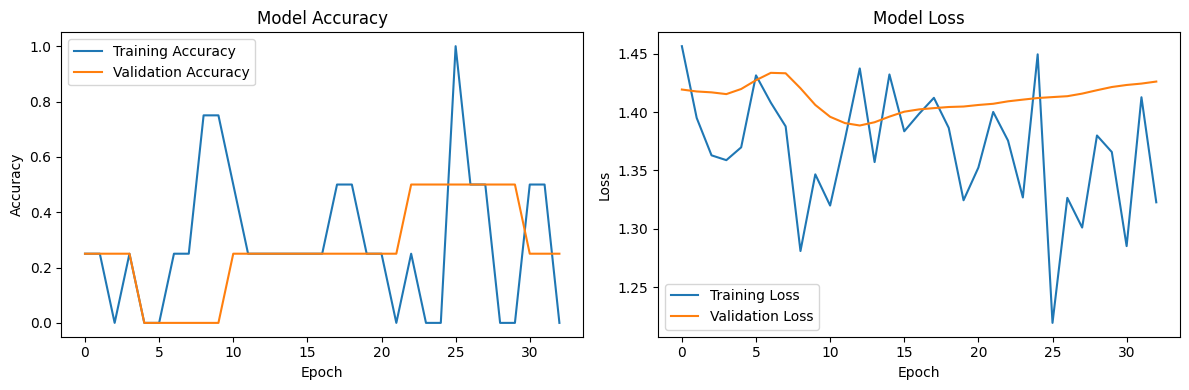

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step

🎯 Validation Predictions:
Sample 1: True=Right, Pred=Right
Sample 2: True=Outside, Pred=Left
Sample 3: True=Left, Pred=Right
Sample 4: True=Center, Pred=Left


In [26]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

# Load your successfully created dataset
X = np.load('/content/penalty_project/X_pose_sequences.npy')
y = np.load('/content/penalty_project/y_shot_labels.npy')

print(f"📦 Loaded dataset: {X.shape} sequences, {y.shape} labels")

# One-hot encode labels (4 classes: 0,1,2,3)
y_categorical = to_categorical(y, num_classes=4)
print(f"One-hot encoded labels: {y_categorical.shape}")

# For small dataset, use leave-one-out or simple split
if len(X) <= 8: # Changed condition to 8 or less
    # With 8 samples and 4 classes, need at least 4 samples for validation with stratify
    X_train, X_val, y_train, y_val = train_test_split(
        X, y_categorical, test_size=0.5, random_state=42, stratify=y # Changed test_size to 0.5
    )
else:
    # Standard split for larger datasets
    X_train, X_val, y_train, y_val = train_test_split(
        X, y_categorical, test_size=0.2, random_state=42, stratify=y
    )

print(f"📊 Split: Train {X_train.shape}, Val {X_val.shape}")

# Build a simpler LSTM model (better for small dataset)
def create_simple_lstm_model():
    model = Sequential([
        LSTM(32, return_sequences=True, input_shape=(30, 132), dropout=0.2),
        LSTM(16, dropout=0.2),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(4, activation='softmax')  # 4 output classes
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Create model
model = create_simple_lstm_model()
print("🧠 LSTM Model Summary:")
model.summary()

# Train with more epochs and early stopping
print("🚀 Starting LSTM training...")
history = model.fit(
    X_train, y_train,
    epochs=100,  # More epochs for small dataset
    batch_size=4,  # Small batch size for 6 training samples
    validation_data=(X_val, y_val),
    verbose=1,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=10, factor=0.5, min_lr=0.0001)
    ]
)

print("✅ LSTM Training Completed!")

# Save the model
model.save('/content/penalty_project/lstm_penalty_predictor.h5')
print("💾 Model saved!")

# Evaluate
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)

print(f"\n📊 Final Results:")
print(f"Training Accuracy: {train_acc:.4f} ({train_acc*100:.1f}%)")
print(f"Validation Accuracy: {val_acc:.4f} ({val_acc*100:.1f}%)")

# Plot results
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Make predictions on validation set
predictions = model.predict(X_val)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_val, axis=1)

print(f"\n🎯 Validation Predictions:")
for i, (true, pred) in enumerate(zip(true_classes, predicted_classes)):
    class_names = ['Outside', 'Left', 'Center', 'Right']
    print(f"Sample {i+1}: True={class_names[true]}, Pred={class_names[pred]}")